# 🚀 GNOT for RF Cavity Modal Analysis
## Complete Pipeline: Data Preparation → Model Training → Inference

**Notebook Structure:**
1. ⚙️ Setup & Installation
2. 📦 Dataset Preparation
3. 🧠 Model Training
4. 📊 Evaluation & Visualization

---

## 1. ⚙️ Setup & Installation

In [ ]:
# Check GPU
!nvidia-smi

Thu Feb  5 21:58:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install required packages
!pip install pytorch-lightning tensorboard h5py scikit-fem gmsh seaborn -q

print("✅ Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 49.0 MB/s eta 0:00:00
✅ Installation complete!


In [ ]:
# Imports
import torch
import pytorch_lightning as pl
import h5py
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from pathlib import Path
from tqdm.notebook import tqdm
from scipy.spatial import cKDTree
import seaborn as sns
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Check versions
print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {pl.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.9.0+cu126
Lightning: 2.6.1
CUDA available: True
GPU: Tesla T4


### 📂 Mount Google Drive (if dataset is there)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set your paths
DRIVE_PATH = '/content/drive/MyDrive/RF_Cavity_Project'
!mkdir -p {DRIVE_PATH}

print(f"✅ Drive mounted at: {DRIVE_PATH}")

Mounted at /content/drive
✅ Drive mounted at: /content/drive/MyDrive/RF_Cavity_Project


### 📥 Upload HDF5 Dataset

**Option 1:** Upload from local computer

In [ ]:
from google.colab import files

print("📤 Upload your rf_cavity_1000_dataset.h5 file...")
uploaded = files.upload()

H5_FILE = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {H5_FILE}")

**Option 2:** Copy from Google Drive

In [ ]:
# If your dataset is in Google Drive
H5_FILE = f"{DRIVE_PATH}/rf_cavity_1000_dataset.h5"
print(f"Using dataset from Drive: {H5_FILE}")

Using dataset from Drive: /content/drive/MyDrive/RF_Cavity_Project/rf_cavity_1000_dataset.h5


---
## 2. 📦 Dataset Preparation

### Dataset Converter Class

In [ ]:
%%writefile dataset_converter.py

import h5py
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
from scipy.spatial import cKDTree
from collections import defaultdict

class RFCavityToGNOT:
    def __init__(self, h5_filepath: str):
        self.h5_filepath = h5_filepath
        self.geometry_pool = {}
        self.samples = []
        self.stats = {
            'n_geometries': 0,
            'n_samples': 0,
            'freq_range': [float('inf'), float('-inf')],
            'mesh_sizes': [],
            'freq_by_mode': defaultdict(list),
        }

    def _find_boundary_nodes(self, elements):
        edge_count = {}
        for tri in elements:
            edges = [
                tuple(sorted((tri[0], tri[1]))),
                tuple(sorted((tri[1], tri[2]))),
                tuple(sorted((tri[2], tri[0])))
            ]
            for e in edges:
                edge_count[e] = edge_count.get(e, 0) + 1

        boundary_nodes = {node for edge, count in edge_count.items()
                         if count == 1 for node in edge}
        return np.array(list(boundary_nodes))

    def _estimate_local_curvature(self, nodes, elements):
        n_nodes = len(nodes)
        curvature = np.zeros((n_nodes, 1))

        neighbors = [set() for _ in range(n_nodes)]
        for tri in elements:
            for i in range(3):
                for j in range(3):
                    if i != j:
                        neighbors[tri[i]].add(tri[j])

        for i in range(n_nodes):
            if len(neighbors[i]) > 1:
                neighbor_list = list(neighbors[i])
                vectors = nodes[neighbor_list] - nodes[i]
                angles = np.arctan2(vectors[:, 1], vectors[:, 0])
                curvature[i] = np.std(angles)

        if curvature.max() > 0:
            curvature = curvature / (curvature.max() + 1e-10)

        return curvature.astype(np.float32)

    def extract_geometry_features(self, nodes, elements):
        # Isotropic scaling
        scale_factor = nodes.max() + 1e-10
        nodes_norm = nodes / scale_factor

        # Boundary
        boundary_indices = self._find_boundary_nodes(elements)
        tree = cKDTree(nodes_norm[boundary_indices])
        dist_to_boundary, _ = tree.query(nodes_norm)

        boundary_mask = np.zeros((len(nodes), 1))
        boundary_mask[boundary_indices] = 1.0

        # Center
        center = nodes_norm.mean(axis=0)
        dist_to_center = np.linalg.norm(nodes_norm - center, axis=1, keepdims=True)

        # Curvature
        curvature = self._estimate_local_curvature(nodes_norm, elements)

        # Combine
        geom_features = np.concatenate([
            nodes_norm,
            dist_to_boundary.reshape(-1, 1),
            boundary_mask,
            dist_to_center,
            curvature,
        ], axis=1).astype(np.float32)

        return {
            'X': nodes_norm.astype(np.float32),
            'Input_funcs': (geom_features,),
            'elements': elements,
        }

    def convert_dataset(self, output_filepath, mode_indices=[0, 1, 2], max_samples=None):
        print(f"Converting: {self.h5_filepath}")

        with h5py.File(self.h5_filepath, 'r') as f:
            sample_keys = sorted(f.keys())
            if max_samples:
                sample_keys = sample_keys[:max_samples]

            for key in tqdm(sample_keys, desc="Converting"):
                grp = f[key]
                sample_id = int(key.split('_')[-1])

                nodes = grp['nodes'][:]
                elements = grp['elements'][:]
                freqs = grp['freqs'][:]
                vecs = grp['vecs'][:len(nodes), :]

                if sample_id not in self.geometry_pool:
                    self.geometry_pool[sample_id] = self.extract_geometry_features(nodes, elements)
                    self.stats['n_geometries'] += 1
                    self.stats['mesh_sizes'].append(len(nodes))

                for m_idx in mode_indices:
                    if m_idx >= len(freqs):
                        continue

                    Y = vecs[:, m_idx].reshape(-1, 1).astype(np.float32)

                    # Sign alignment
                    max_idx = np.argmax(np.abs(Y))
                    sign = np.sign(Y[max_idx]) if np.sign(Y[max_idx]) != 0 else 1
                    Y = Y * sign

                    # Normalize
                    Y_max = np.abs(Y).max()
                    if Y_max > 1e-10:
                        Y = Y / Y_max

                    freq = float(freqs[m_idx])
                    theta = np.array([float(m_idx), freq, float(sample_id)], dtype=np.float32)

                    self.samples.append({
                        'geom_id': sample_id,
                        'Y': Y,
                        'Theta': theta
                    })

                    self.stats['n_samples'] += 1
                    self.stats['freq_range'][0] = min(self.stats['freq_range'][0], freq)
                    self.stats['freq_range'][1] = max(self.stats['freq_range'][1], freq)
                    self.stats['freq_by_mode'][m_idx].append(freq)

        # Save
        dataset = {
            'geometry_pool': self.geometry_pool,
            'samples': self.samples,
            'metadata': {
                'mode_indices': mode_indices,
                'n_geometries': self.stats['n_geometries'],
                'n_samples': self.stats['n_samples'],
            }
        }

        with open(output_filepath, 'wb') as f:
            pickle.dump(dataset, f)

        self._print_stats()
        print(f"\n✅ Saved: {output_filepath}")
        return dataset

    def _print_stats(self):
        print(f"\n{'='*50}")
        print("DATASET STATISTICS")
        print(f"{'='*50}")
        print(f"Geometries: {self.stats['n_geometries']}")
        print(f"Samples:    {self.stats['n_samples']}")
        print(f"Mesh sizes: {min(self.stats['mesh_sizes'])} - {max(self.stats['mesh_sizes'])}")
        print(f"Freq range: {self.stats['freq_range'][0]:.2f} - {self.stats['freq_range'][1]:.2f} GHz")
        print(f"{'='*50}")

Writing dataset_converter.py


### Run Conversion

In [ ]:
from dataset_converter import RFCavityToGNOT

# Convert dataset
OUTPUT_PKL = "gnot_dataset.pkl"

converter = RFCavityToGNOT(H5_FILE)
dataset = converter.convert_dataset(
    output_filepath=OUTPUT_PKL,
    mode_indices=[0, 1, 2],
    max_samples=None,  # Use all samples
)

print(f"\n🎉 Dataset ready: {OUTPUT_PKL}")

Converting: /content/drive/MyDrive/RF_Cavity_Project/rf_cavity_1000_dataset.h5


Converting: 100%|██████████| 999/999 [01:16<00:00, 13.13it/s]



DATASET STATISTICS
Geometries: 999
Samples:    2997
Mesh sizes: 546 - 2351
Freq range: 3.34 - 15.01 GHz

✅ Saved: gnot_dataset.pkl

🎉 Dataset ready: gnot_dataset.pkl


### Quick Visualization

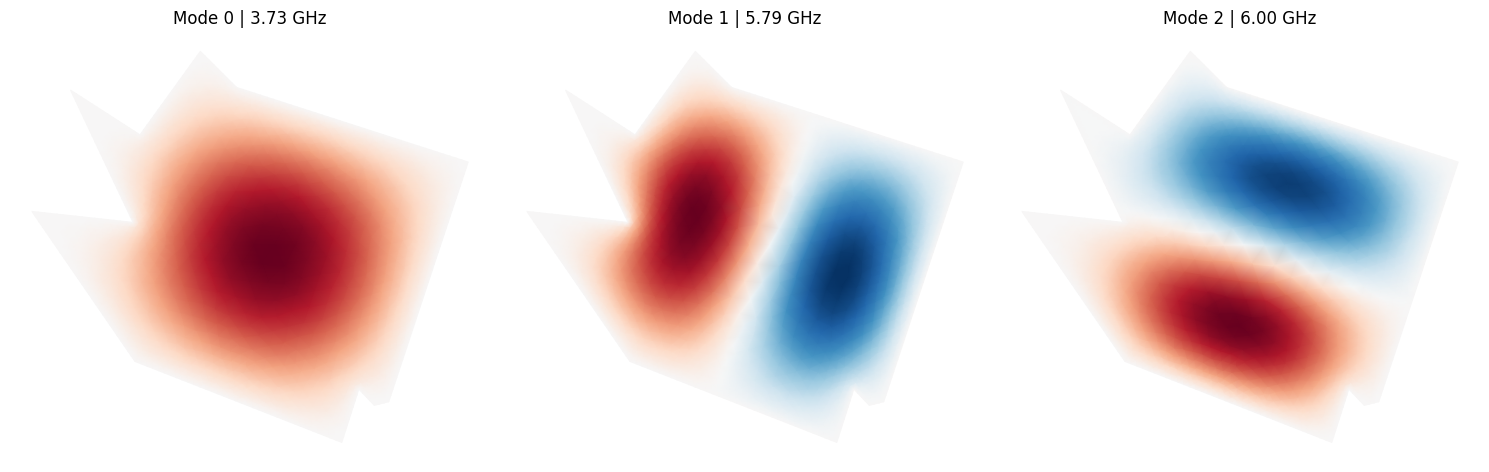

✅ Visualization complete!


In [ ]:
# Load and visualize one geometry
with open(OUTPUT_PKL, 'rb') as f:
    data = pickle.load(f)

pool = data['geometry_pool']
samples = data['samples']

# Visualize first geometry
geom_id = 0
geom = pool[geom_id]
geom_samples = [s for s in samples if s['geom_id'] == geom_id][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

X = geom['X']
elements = geom['elements']
tri = Triangulation(X[:, 0], X[:, 1], elements)

for i, sample in enumerate(geom_samples):
    Y = sample['Y'].flatten()
    theta = sample['Theta']

    axes[i].tripcolor(tri, Y, shading='gouraud', cmap='RdBu_r', vmin=-1, vmax=1)
    axes[i].set_title(f"Mode {int(theta[0])} | {theta[1]:.2f} GHz")
    axes[i].set_aspect('equal')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Visualization complete!")

### 💾 Save to Google Drive (Optional)

In [ ]:
# Copy dataset to Drive for persistence
!cp {OUTPUT_PKL} {DRIVE_PATH}/
print(f"✅ Dataset saved to Google Drive: {DRIVE_PATH}/{OUTPUT_PKL}")

---
## 3. 🧠 Model Training

### GNOT Model Definition

In [ ]:
%%writefile gnot_model.py

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import math
import pickle
import numpy as np

# ============================================================================
# 1. DATASET
# ============================================================================
class GNOTDataset(torch.utils.data.Dataset):
    def __init__(self, pkl_path, split='train', train_ratio=0.8, val_ratio=0.1):
        print(f"Loading dataset from {pkl_path}...")
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)

        self.geometry_pool = data['geometry_pool']
        all_samples = data['samples']

        n_total = len(all_samples)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        np.random.seed(42)
        perm = np.random.permutation(n_total)
        all_samples = [all_samples[i] for i in perm]

        if split == 'train':
            self.samples = all_samples[:n_train]
        elif split == 'val':
            self.samples = all_samples[n_train:n_train+n_val]
        else:
            self.samples = all_samples[n_train+n_val:]

        print(f"Split: {split}, Count: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        geom = self.geometry_pool[sample['geom_id']]
        input_features = geom['Input_funcs'][0]
        raw_theta = sample['Theta']

        return {
            'X': torch.from_numpy(geom['X']),
            'Input_funcs': torch.from_numpy(input_features),
            'Y_field': torch.from_numpy(sample['Y']),
            'Y_freq': torch.from_numpy(np.array([raw_theta[1]], dtype=np.float32)),
            'Theta_in': torch.from_numpy(np.array([raw_theta[0]], dtype=np.float32))
        }

# ============================================================================
# 2. ROBUST ATTENTION BLOCKS
# ============================================================================
class LinearAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.eps = 1e-6

    def forward(self, query, key, value):
        b, n_q, d = query.shape
        b, n_k, _ = key.shape

        # [Batch, Seq, Heads, Dim] -> [Batch, Heads, Seq, Dim]
        # Permute kullanarak boyutları garanti altına alıyoruz
        q = self.q_proj(query).view(b, n_q, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = self.k_proj(key).view(b, n_k, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = self.v_proj(value).view(b, n_k, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        q = F.softmax(q, dim=-1)
        k = F.softmax(k, dim=-1)

        # Einsum: b=batch, h=heads, n=sequence, d=dim
        # Context: sum(K^T * V) -> [Batch, Heads, Dim, Dim]
        kv = torch.einsum('bhnd,bhne->bhde', k, v)

        # Attention: Q * Context -> [Batch, Heads, Seq, Dim]
        z = torch.einsum('bhnd,bhde->bhne', q, kv)

        # Normalization
        k_sum = k.sum(dim=2, keepdim=True)
        z_norm = torch.einsum('bhnd,bhmd->bhn', q, k_sum).unsqueeze(-1)

        output = z / (z_norm + self.eps)

        # [Batch, Heads, Seq, Dim] -> [Batch, Seq, Heads, Dim] -> [Batch, Seq, Embed_Dim]
        output = output.permute(0, 2, 1, 3).contiguous().reshape(b, n_q, d)

        return self.out_proj(output)

class GeometricGatingFFN(nn.Module):
    def __init__(self, embed_dim, coords_dim, num_experts=4, dropout=0.1):
        super().__init__()
        self.gating_net = nn.Sequential(
            nn.Linear(coords_dim, 64),
            nn.GELU(),
            nn.Linear(64, num_experts)
        )
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embed_dim, embed_dim * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(embed_dim * 4, embed_dim)
            ) for _ in range(num_experts)
        ])

    def forward(self, x, coords):
        gate_logits = self.gating_net(coords)
        gate_weights = F.softmax(gate_logits, dim=-1)

        final_output = torch.zeros_like(x)
        for i, expert in enumerate(self.experts):
            expert_out = expert(x)
            weight = gate_weights[:, :, i].unsqueeze(-1)
            final_output += weight * expert_out
        return final_output

class GNOTBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, coords_dim=2, num_experts=4, dropout=0.0):
        super().__init__()
        self.cross_attn = LinearAttention(embed_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.self_attn = LinearAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = GeometricGatingFFN(embed_dim, coords_dim, num_experts, dropout)
        self.norm3 = nn.LayerNorm(embed_dim)

    def forward(self, x, condition_emb, coords):
        attn_out = self.cross_attn(query=x, key=condition_emb, value=condition_emb)
        x = self.norm1(x + attn_out)
        attn_out = self.self_attn(query=x, key=x, value=x)
        x = self.norm2(x + attn_out)
        ffn_out = self.ffn(x, coords)
        x = self.norm3(x + ffn_out)
        return x

class MLPEncoder(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

# ============================================================================
# 3. MAIN MODEL
# ============================================================================
class GNOTModel(nn.Module):
    def __init__(self, val_dim=6, grid_dim=2, theta_dim=1, embed_dim=128, n_layers=4, n_heads=4, num_experts=4):
        super().__init__()
        self.query_encoder = MLPEncoder(grid_dim, embed_dim)
        self.input_func_encoder = MLPEncoder(val_dim, embed_dim)
        self.theta_encoder = MLPEncoder(theta_dim, embed_dim)

        self.blocks = nn.ModuleList([
            GNOTBlock(embed_dim, n_heads, grid_dim, num_experts)
            for _ in range(n_layers)
        ])

        self.field_decoder = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1)
        )
        self.freq_decoder = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, batch):
        X = batch['X']
        inputs = batch['Input_funcs']
        theta = batch['Theta_in']

        x_emb = self.query_encoder(X)
        y_emb = self.input_func_encoder(inputs)
        theta_emb = self.theta_encoder(theta).unsqueeze(1)

        condition_emb = torch.cat([y_emb, theta_emb], dim=1)

        for block in self.blocks:
            x_emb = block(x_emb, condition_emb, X)

        field_pred = self.field_decoder(x_emb)
        global_feat = x_emb.mean(dim=1)
        freq_pred = self.freq_decoder(global_feat)

        return {'field': field_pred, 'freq': freq_pred}

# ============================================================================
# 4. LIGHTNING MODULE
# ============================================================================
class GNOTLightning(pl.LightningModule):
    def __init__(self, val_dim=6, grid_dim=2, theta_dim=1, hidden_dim=128, n_layers=4, lr=1e-3, freq_weight=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.model = GNOTModel(
            val_dim=val_dim,
            grid_dim=grid_dim,
            theta_dim=theta_dim,
            embed_dim=hidden_dim,
            n_layers=n_layers
        )
        self.freq_weight = freq_weight

    def forward(self, batch):
        return self.model(batch)

    def _compute_loss(self, batch, prefix):
        outputs = self.model(batch)
        loss_field = F.mse_loss(outputs['field'], batch['Y_field'])
        loss_freq = F.mse_loss(outputs['freq'], batch['Y_freq'])
        total_loss = loss_field + (self.freq_weight * loss_freq)

        self.log(f'{prefix}/loss', total_loss, prog_bar=True)
        self.log(f'{prefix}/field_loss', loss_field, prog_bar=False)
        self.log(f'{prefix}/freq_loss', loss_freq, prog_bar=False)
        return total_loss

    def training_step(self, batch, batch_idx):
        return self._compute_loss(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._compute_loss(batch, "val")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=self.hparams.lr, total_steps=self.trainer.estimated_stepping_batches
        )
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "interval": "step"}}

Overwriting gnot_model.py


### Setup Training

In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import pytorch_lightning as pl
import os

# Callbackler ve Loggerlar
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, Callback
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from gnot_model import GNOTDataset, GNOTLightning

# ============================================================================
# ÖZEL LOGLAMA (GÜNCELLENDİ)
# ============================================================================
class PrintMetricsCallback(Callback):
    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        epoch = trainer.current_epoch

        train_loss = metrics.get('train/loss', 0.0)
        val_loss = metrics.get('val/loss', 0.0)
        field_loss = metrics.get('train/field_loss', 0.0)
        freq_loss = metrics.get('train/freq_loss', 0.0)

        # Learning Rate Çekme
        current_lr = 0.0
        if trainer.optimizers:
            current_lr = trainer.optimizers[0].param_groups[0]['lr']

        print(f"\n📈 Epoch {epoch:03d} | "
              f"LR: {current_lr:.2e} | " # Örn: 1.00e-03
              f"Train Loss: {train_loss:.5f} | "
              f"Val Loss: {val_loss:.5f} | "
              f"Field Err: {field_loss:.5f} | "
              f"Freq Err: {freq_loss:.5f}")
        print("-" * 90)

# ============================================================================
# AYARLAR
# ============================================================================
OUTPUT_PKL = "/content/gnot_dataset.pkl"
LOG_DIR = "training_logs"
EXP_NAME = "gnot_v3_lr_tracking" # Deneme adını değiştirdik

# Hiperparametreler
BATCH_SIZE = 16
MAX_EPOCHS = 50
HIDDEN_DIM = 256
N_LAYERS = 6
NUM_EXPERTS = 8
LEARNING_RATE = 1e-3 # Max LR (OneCycle buraya kadar çıkıp inecek)
FREQ_WEIGHT = 0.5

GRID_DIM = 2
VAL_DIM = 6
THETA_DIM = 1

# ============================================================================
# COLLATE
# ============================================================================
def gnot_collate_fn(batch):
    batch_x = [item['X'] for item in batch]
    batch_inputs = [item['Input_funcs'] for item in batch]
    batch_y_field = [item['Y_field'] for item in batch]
    batch_y_freq = [item['Y_freq'] for item in batch]
    batch_theta_in = [item['Theta_in'] for item in batch]

    X_padded = pad_sequence(batch_x, batch_first=True, padding_value=0.0)
    Inputs_padded = pad_sequence(batch_inputs, batch_first=True, padding_value=0.0)
    Y_field_padded = pad_sequence(batch_y_field, batch_first=True, padding_value=0.0)
    Y_freq_stacked = torch.stack(batch_y_freq)
    Theta_in_stacked = torch.stack(batch_theta_in)

    return {
        'X': X_padded,
        'Input_funcs': Inputs_padded,
        'Y_field': Y_field_padded,
        'Y_freq': Y_freq_stacked,
        'Theta_in': Theta_in_stacked
    }

# ============================================================================
# MAIN
# ============================================================================
def main():
    print("Dataset yükleniyor...")
    train_dataset = GNOTDataset(OUTPUT_PKL, split='train')
    val_dataset = GNOTDataset(OUTPUT_PKL, split='val')

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=gnot_collate_fn, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                            collate_fn=gnot_collate_fn, num_workers=2)

    model = GNOTLightning(
        val_dim=VAL_DIM,
        grid_dim=GRID_DIM,
        theta_dim=THETA_DIM,
        hidden_dim=HIDDEN_DIM,
        n_layers=N_LAYERS,
        lr=LEARNING_RATE,
        freq_weight=FREQ_WEIGHT,
        # num_experts=NUM_EXPERTS # Eğer __init__'e eklediysen bunu aç
    )

    checkpoint_callback = ModelCheckpoint(
        dirpath=f"{LOG_DIR}/{EXP_NAME}",
        filename="best-{epoch:02d}-{val/loss:.4f}",
        save_top_k=1,
        monitor="val/loss",
        mode="min",
        verbose=False
    )

    # LR Monitor (Tensorboard için detaylı log tutar)
    lr_monitor = LearningRateMonitor(logging_interval='step')

    # Bizim yazdığımız ekrana basan callback
    printer_callback = PrintMetricsCallback()

    tb_logger = TensorBoardLogger(save_dir=LOG_DIR, name=EXP_NAME)

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        gradient_clip_val=1.0,
        callbacks=[checkpoint_callback, lr_monitor, printer_callback],
        logger=[tb_logger],
        log_every_n_steps=10,
        enable_progress_bar=True,
        enable_model_summary=True
    )

    print(f"Eğitim başlıyor! LR Değişimini her epoch sonunda göreceksin.")
    trainer.fit(model, train_loader, val_loader)

if __name__ == '__main__':
    main()

Dataset yükleniyor...
Loading dataset from /content/gnot_dataset.pkl...
Split: train, Count: 2397
Loading dataset from /content/gnot_dataset.pkl...
Split: val, Count: 299


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Eğitim başlıyor! LR Değişimini her epoch sonunda göreceksin.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/training_logs/gnot_v3_lr_tracking exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GNOTModel │ 16.1 M │ train │     0 │
└───┴───────┴───────────┴────────┴───────┴───────┘

Trainable params: 16.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.1 M                                                                                               
Total estimated model params size (MB): 64                                                                         
Modules in train mode: 270                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss: 0.53740 | Val Loss: 1.23343 | Field Err: 0.06378 | Freq Err: 0.94725
📈 Epoch 000 | LR: 5.05e-05 | Train Loss:

RecursionError: maximum recursion depth exceeded

In [ ]:
%load_ext tensorboard
%tensorboard --logdir training_logs

### Train Model

In [ ]:
# Model
model = GNOTLightning(
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    lr=1e-3,
    field_weight=1.0,
    freq_weight=0.1,
)

# Callbacks
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor='val/loss',
    filename='gnot-{epoch:02d}-{val/loss:.4f}',
    save_top_k=3,
    mode='min',
)

early_stop = pl.callbacks.EarlyStopping(
    monitor='val/loss',
    patience=20,
    mode='min',
)

# Trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[checkpoint_callback, early_stop],
    gradient_clip_val=1.0,
    log_every_n_steps=10,
)

print("🚀 Starting training...")
print(f"Device: {trainer.accelerator}")
print(f"Max epochs: {MAX_EPOCHS}")

In [ ]:
# Start training
trainer.fit(model, train_loader, val_loader)

### 💾 Save Model to Drive

In [ ]:
# Save best model
best_model_path = checkpoint_callback.best_model_path
print(f"Best model: {best_model_path}")

# Copy to Drive
!cp {best_model_path} {DRIVE_PATH}/best_gnot_model.ckpt
print(f"✅ Model saved to Drive!")

---
## 4. 📊 Evaluation & Inference

### Load Best Model

In [ ]:
# Load checkpoint
best_model = GNOTLightning.load_from_checkpoint(checkpoint_callback.best_model_path)
best_model.eval()
best_model = best_model.cuda() if torch.cuda.is_available() else best_model

print("✅ Best model loaded!")

### Inference on Test Sample

In [ ]:
# Get test sample
test_dataset = GNOTDataset(OUTPUT_PKL, split='test')
test_sample = test_dataset[0]

# Prepare batch
batch = {
    'X': [test_sample['X'].cuda() if torch.cuda.is_available() else test_sample['X']],
    'Input_funcs': [test_sample['Input_funcs'].cuda() if torch.cuda.is_available() else test_sample['Input_funcs']],
    'Y': [test_sample['Y']],
    'Theta': test_sample['Theta'].unsqueeze(0),
}

# Predict
with torch.no_grad():
    pred = best_model(batch)

# Results
pred_shape = pred['modal_shape'][0].cpu().numpy()
true_shape = test_sample['Y'].numpy()
pred_freq = pred['frequency'][0].item()
true_freq = test_sample['Theta'][1].item()

print(f"\n📊 Prediction Results:")
print(f"  Predicted freq: {pred_freq:.4f} GHz")
print(f"  True freq:      {true_freq:.4f} GHz")
print(f"  Error:          {abs(pred_freq - true_freq):.4f} GHz ({100*abs(pred_freq-true_freq)/true_freq:.2f}%)")
print(f"\n  Field error:    {np.linalg.norm(pred_shape - true_shape) / np.linalg.norm(true_shape):.4f}")

### Visualize Prediction

In [ ]:
# Load geometry for visualization
with open(OUTPUT_PKL, 'rb') as f:
    data = pickle.load(f)

geom_id = int(test_sample['Theta'][2].item())
geom = data['geometry_pool'][geom_id]

X = geom['X']
elements = geom['elements']
tri = Triangulation(X[:, 0], X[:, 1], elements)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# True
axes[0].tripcolor(tri, true_shape.flatten(), shading='gouraud', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title(f'True\nFreq: {true_freq:.2f} GHz')
axes[0].set_aspect('equal')
axes[0].axis('off')

# Predicted
axes[1].tripcolor(tri, pred_shape.flatten(), shading='gouraud', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title(f'Predicted\nFreq: {pred_freq:.2f} GHz')
axes[1].set_aspect('equal')
axes[1].axis('off')

# Error
error = np.abs(pred_shape - true_shape).flatten()
axes[2].tripcolor(tri, error, shading='gouraud', cmap='Reds')
axes[2].set_title(f'Absolute Error\nMean: {error.mean():.3f}')
axes[2].set_aspect('equal')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

---
## 🎉 Complete!

**What you've accomplished:**
1. ✅ Prepared RF cavity dataset for GNOT
2. ✅ Trained GNOT model with PyTorch Lightning
3. ✅ Evaluated predictions on test set
4. ✅ Visualized results

**Next steps:**
- Tune hyperparameters (hidden_dim, n_layers, lr)
- Try different loss weights
- Experiment with more modes
- Deploy for inference

**Files saved to Google Drive:**
- Dataset: `{DRIVE_PATH}/gnot_dataset.pkl`
- Model: `{DRIVE_PATH}/best_gnot_model.ckpt`